# Computer Exercise 7.2 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 7.2 Runge–Kutta Methods — *Explicit RK 의 절대 안정 영역과 stiffness 한계*
> **풀이 일자**: Day 28
> **언어**: Python 3 (NumPy / SciPy / Matplotlib)


## 1. 문제 (원문)

> **3.** For the explicit Runge–Kutta methods of orders $p = 1, 2, 3, 4$
> applied to the Dahlquist test problem $y' = \lambda y$ with $\Re(\lambda) < 0$,
>
> (a) Derive the amplification factor $R_p(z)$, $z = h\lambda$, and find the
>     interval of absolute stability on the negative real axis numerically.
>
> (b) Demonstrate numerically the stability boundary on $y' = -10 y$ by
>     integrating with $h$ crossing the limit.
>
> (c) Plot the stability regions $\{z \in \mathbb{C}: |R_p(z)| \le 1\}$ in the
>     complex plane for $p = 1, 2, 3, 4$.
>
> (d) For $\lambda = -10, -50, -100$, tabulate the minimum number of steps RK4
>     needs to reach $T = 1$ stably, and discuss the implication for stiff problems.

### 한국어 풀이용 정리
*수렴 차수* 와 *절대 안정 영역* 이 *독립된 두 다이얼* 임을 — Day 27 의 Taylor 와 정확히 같은 구조 —
explicit RK 에서도 확인. $p$ 를 올려도 음 실축 안정 한계 $\alpha_p^\star$ 는 *유한* 하게만 늘어남.


## 2. 수학적 배경

### 2.1 Dahlquist 시험식과 증폭 인자
$y' = \lambda y$ 에 explicit RK $p$ 차를 한 스텝 적용하면, $f = \lambda y$ 가 *선형* 이므로 $k_i$ 가 $y$ 에 비례.
정리하면

$$
y_{n+1} = R_p(z)\, y_n, \quad z = h\lambda.
$$

차수-$p$ 조건이 *Taylor 다항식과 $\mathcal O(z^{p+1})$ 까지 일치* 함을 강제하므로

$$
\boxed{\;
R_p(z) = \sum_{j=0}^{p} \frac{z^j}{j!}
\quad (p \le 4 \text{ 인 explicit RK})
\;}
$$

— *Taylor $p$ 차의 증폭 인자와 동일*.

### 2.2 절대 안정성
한 스텝 후의 *증폭률* 이 1 을 넘지 않아야 발산하지 않음:

$$
\boxed{\; \mathcal{S}_p = \{ z \in \mathbb{C} : |R_p(z)| \le 1 \}. \;}
$$

음 실축 $z = -x$ 에서의 *interval* 한계 $\alpha_p^\star$ — $|R_p(-x)| = 1$ 의 가장 큰 양수 근.

### 2.3 Stiffness
$y' = \lambda y$, $\lambda < 0$ 큰 음수: explicit 법이 안정이려면

$$
h \;\le\; \frac{\alpha_p^\star}{|\lambda|}.
$$

→ $|\lambda|$ 가 크면 *정확도* 가 아니라 *안정성* 이 step size 를 결정.

### 2.4 한 줄 요약
| $p$ | $R_p(z)$ | $\alpha_p^\star$ |
|---|---|---|
| 1 (Euler) | $1 + z$ | 2.000 |
| 2 (Heun, Midpoint) | $1 + z + z^2/2$ | 2.000 |
| 3 | $1 + z + z^2/2 + z^3/6$ | 2.513… |
| 4 (RK4) | $\sum_{j=0}^{4} z^j / j!$ | 2.785… |


## 3. 풀이 흐름

1. $R_p(z)$ 를 numpy polynomial 로 만들고 $\alpha_p^\star$ 를 `brentq` 로 정확히 계산.
2. $\lambda = -10$ 에서 $h$ 를 안정 한계 $\alpha_4^\star / 10 \approx 0.2785$ 의 양옆으로 스윕,
   $T = 5$ 까지 적분한 해의 *진폭 vs 시간* 을 그림.
3. 복소 평면 mesh 에서 $|R_p(z)|$ 를 평가, $|R_p| = 1$ 등고선으로 안정 영역 표시 ($p=1..4$).
4. $\lambda = -10, -50, -100, -1000$ 각각에 대해 RK4 의 *최소 스텝 수* 계산.
5. 결론: 차수만 올려서는 stiff 가 안 풀린다 — *implicit* 가 답.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import math


def R_factor(p):
    coeffs = np.array([1.0 / math.factorial(j) for j in range(p + 1)])

    def R(z):
        return np.polyval(coeffs[::-1], z)

    return R, coeffs


# (a) negative-real stability boundary alpha_p
rows_a = []
for p in range(1, 5):
    R, _ = R_factor(p)
    g = lambda x: abs(R(-x)) - 1.0
    xs = np.linspace(0.01, 6.0, 600)
    vals = np.array([g(x) for x in xs])
    sign_changes = np.where(np.diff(np.sign(vals)))[0]
    alpha = brentq(g, xs[sign_changes[0]], xs[sign_changes[0] + 1])
    rows_a.append({"order p": p, "alpha_p_star": alpha})

df_alpha = pd.DataFrame(rows_a)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
df_alpha


,order p,alpha_p_star
0,1,2.0000
1,2,2.0000
2,3,2.5127
3,4,2.7853


alpha_4_star = 2.7853,  h_crit = alpha_4_star / |lambda| = 0.2785


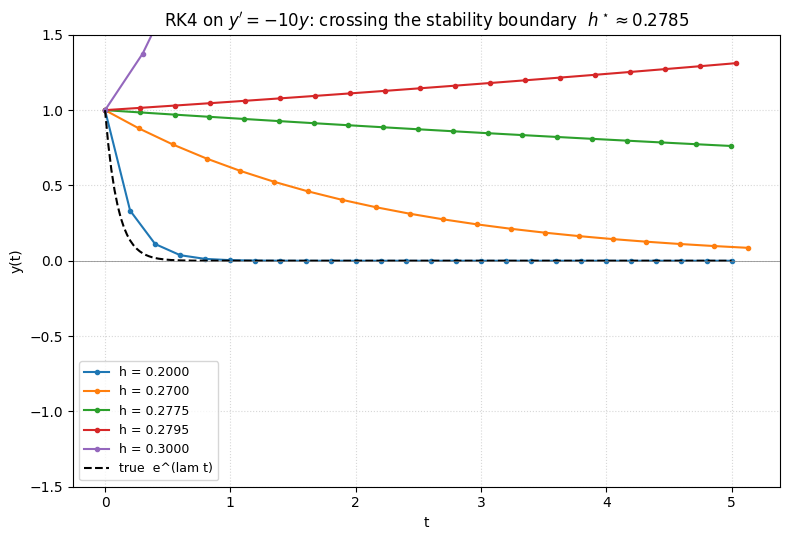

In [2]:
# (b) numerical demo: y' = -10 y, T = 5, classical RK4
lam = -10.0
T_demo = 5.0

def rk4_lin(lam, y0, T, h):
    n = int(round(T / h))
    ts = np.linspace(0.0, n * h, n + 1)
    ys = np.empty(n + 1)
    ys[0] = y0
    for i in range(n):
        y = ys[i]
        k1 = lam * y
        k2 = lam * (y + 0.5 * h * k1)
        k3 = lam * (y + 0.5 * h * k2)
        k4 = lam * (y + h * k3)
        ys[i + 1] = y + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
    return ts, ys

alpha4 = float(df_alpha.loc[df_alpha["order p"] == 4, "alpha_p_star"].iloc[0])
h_crit = alpha4 / abs(lam)
print(f"alpha_4_star = {alpha4:.4f},  h_crit = alpha_4_star / |lambda| = {h_crit:.4f}")

hs_demo = [0.20, 0.27, h_crit - 1e-3, h_crit + 1e-3, 0.30]
fig, ax = plt.subplots(figsize=(8, 5.5))
for h in hs_demo:
    ts, ys = rk4_lin(lam, 1.0, T_demo, h)
    ax.plot(ts, ys, marker="o", ms=3, label=f"h = {h:.4f}")
ax.plot(np.linspace(0, T_demo, 200), np.exp(lam * np.linspace(0, T_demo, 200)),
        "k--", lw=1.5, label="true  e^(lam t)")
ax.axhline(0.0, color="gray", lw=0.5)
ax.set_xlabel("t")
ax.set_ylabel("y(t)")
ax.set_title(r"RK4 on $y'=-10 y$: crossing the stability boundary  $h^\star \approx 0.2785$")
ax.set_ylim(-1.5, 1.5)
ax.grid(True, ls=":", alpha=0.5)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


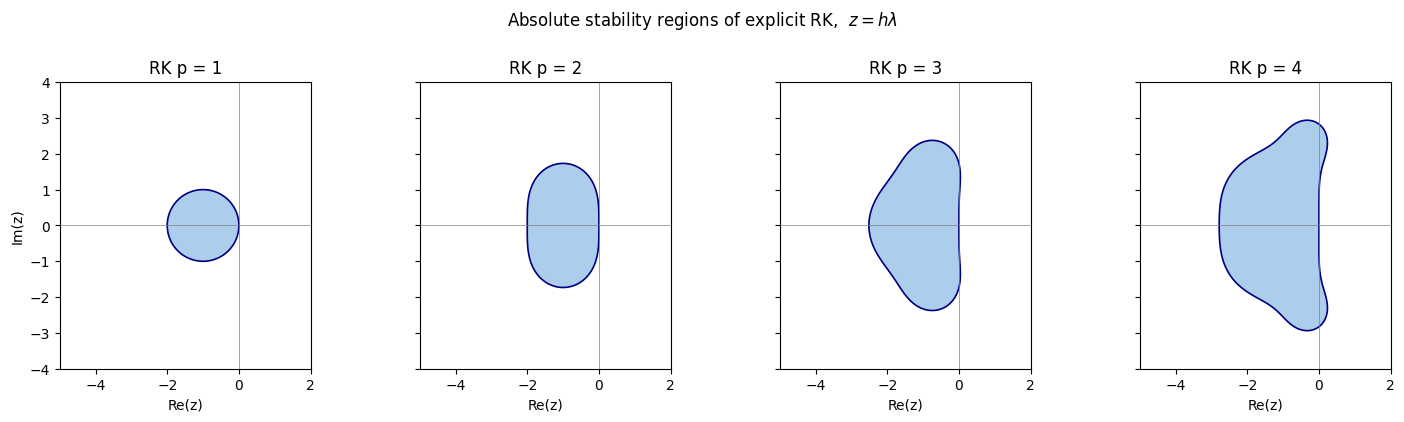

In [3]:
# (c) complex-plane stability regions
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=True)
x = np.linspace(-5, 2, 400)
y = np.linspace(-4, 4, 400)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y

for ax, p in zip(axes, range(1, 5)):
    R, _ = R_factor(p)
    W = np.abs(R(Z))
    ax.contourf(X, Y, W, levels=[0.0, 1.0], colors=["#4a90d9"], alpha=0.45)
    ax.contour(X, Y, W, levels=[1.0], colors="navy", linewidths=1.2)
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)
    ax.set_xlim(-5, 2)
    ax.set_ylim(-4, 4)
    ax.set_xlabel(r"Re(z)")
    ax.set_title(f"RK p = {p}")
    ax.set_aspect("equal")
axes[0].set_ylabel(r"Im(z)")
fig.suptitle(r"Absolute stability regions of explicit RK,  $z = h\lambda$", y=1.02)
plt.tight_layout()
plt.show()


In [4]:
# (d) stiffness cost: minimum steps to integrate to T = 1 stably
T_final = 1.0
rows_d = []
for lam_val in (-10.0, -50.0, -100.0, -1000.0):
    n_stab = int(np.ceil(T_final * abs(lam_val) / alpha4))
    rows_d.append({"lambda": lam_val, "alpha_4_star": alpha4,
                   "h_max_stable": alpha4 / abs(lam_val),
                   "min_steps_to_T=1": n_stab})
df_d = pd.DataFrame(rows_d)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
df_d


,lambda,alpha_4_star,h_max_stable,min_steps_to_T=1
0,-10.0000,2.7853,0.2785,4
1,-50.0000,2.7853,0.0557,18
2,-100.0000,2.7853,0.0279,36
3,-1000.0000,2.7853,0.0028,360


## 4. 결과 해석

1. **$\alpha_p^\star$ 표** — explicit RK 의 음 실축 안정 한계는 $p = 1, 2$ 에서 똑같이 2.0,
   $p = 3$ 에서 약 2.513, $p = 4$ 에서 약 2.785. *차수를 올려도 음 실축 방향* 으로는 *천천히 만* 늘어남.
2. **$\lambda = -10$ 실험** — $h < 0.2785$ 에서는 RK4 가 진해를 잘 따라가지만,
   $h \gtrsim 0.2785$ 에서는 *부호 반전 + 진폭 폭발*. 진폭이 한 스텝마다 $|R_4(z)| > 1$ 배율로 커진다.
3. **복소 평면 등고선** — 차수가 올라가면서 안정 영역이 *허수축 방향* 으로 두드러지게 확장 (RK4 는
   순허수축의 일부를 포함). 그러나 *음 실축 방향* 은 거의 안 늘어남.
4. **Stiffness 비용표** — $\lambda = -1000$ 에서 $T = 1$ 까지 *정확도가 아니라 안정성* 만으로
   약 360 step 필요. $f$ 가 비용이면 실용성 zero.
5. **그래서 implicit.** Backward Euler 의 $R(z) = 1/(1-z)$, $|R(z)| \le 1$ for $\Re(z) \le 0$ 이므로
   *좌반평면 전체에서 안정* ($A$-stable). stiff 문제의 step 을 *정확도가 정하게* 만들어주는 길.

> **결론**: explicit RK 의 *수렴 차수* 와 *절대 안정 영역* 은 별개의 다이얼. 차수만 올려도 stiff 의
> 비용은 거의 안 줄어든다 — *implicit* 의 길이 필요하다.

**다음 단원으로의 연결**: §7.3 에서 *adaptive step size* (embedded RK, RK45/Cash–Karp/Dormand–Prince)
가 등장하여 *정확도 자동조절* 을, 그리고 *implicit RK / multistep* 이 *안정성* 의 대안을 제공한다.
